In [1]:
import time
import psutil
import numpy as np
from dask.distributed import Client, SpecCluster, Worker, wait
import matplotlib.pyplot as plt

Modelo de Ising 2D (MCMC / Algoritmo de Metropolis):

* Red de espines $s_i \in \{-1, +1\}$ en una cuadrícula $L \times L$.

* Objetivo: Calcular la magnetización media $\langle \vert{}M\vert{} \rangle$ y la energía media $\langle E \rangle$ en función de la temperatura $T$ para observar la transición de fase ferromagnética ($T_c \approx 2.269 \, J/k_B$).

* Uso con Dask: Cada job simula una réplica a una temperatura $T$ distinta en paralelo (parameter sweep).


El criterio de Metropolis-Hastings garantiza formalmente la **condición de balance detallado** para que la distribución estacionaria de la cadena de Markov converja a la distribución canónica de Boltzmann:

$$P(\text{aceptar } \mu \to \nu) = \min\left(1, \, e^{-\frac{\Delta E}{k_B T}}\right)$$

Desglosado en dos ramas de condición `if`:

1. **$\Delta E \le 0$ (Transición energéticamente favorable o neutra):**
* $e^{-\Delta E / T} \ge 1$, por lo que la probabilidad de aceptación es **$1$ (100%)**.
* El sistema minimiza su energía de forma determinista si la propuesta lo favorece.


2. **$\Delta E > 0$ (Transición energéticamente desfavorable):**
* $0 < e^{-\Delta E / T} < 1$.
* Se genera un número aleatorio uniforme $u \sim \mathcal{U}(0, 1)$. El cambio solo se acepta si $u < e^{-\Delta E / T}$.
* Físicamente representa la **fluctuación térmica**: el baño térmico a temperatura $T$ cede energía espontáneamente para superar una barrera de potencial, permitiendo al sistema explorar el espacio de fases y no quedarse atrapado en mínimos locales de energía.



A temperaturas altas ($T \to \infty$), $e^{-\Delta E / T} \to 1$ (el desorden entrópico domina y casi todo se acepta). A temperaturas casi nulas ($T \to 0$), $e^{-\Delta E / T} \to 0$ (solo se aceptan bajadas de energía, congelándose en el estado fundamental).

--- 

La variación energética tiene una expresión que viene de la expresión del Hamiltoniano de Ising:

Viene directamente del **Hamiltoniano del modelo de Ising** sin campo magnético externo:

$$H = -J \sum_{\langle k, l \rangle} s_k s_l$$

donde la suma $\langle k, l \rangle$ recorre todos los pares de primeros vecinos y fijamos el acoplamiento ferromagnético $J = 1$.

---

### Derivación paso a paso

Si nos centramos en un único espín $s_i$ en la posición $(i, j)$ y aislamos su contribución a la energía total del sistema:

1. **Energía inicial ($E_{\text{inicial}}$):**
La parte del Hamiltoniano que involucra al espín $s_i$ es únicamente la interacción con sus 4 primeros vecinos:

$$E_{\text{inicial}}(s_i) = -J \cdot s_i \sum_{j \in \text{vecinos}} s_j = -s_i \cdot \text{nb\_sum}$$


2. **Energía final ($E_{\text{final}}$):**
Al proponer el volteo (*spin-flip*), el nuevo valor es $s_i' = -s_i$, mientras que los vecinos permanecen inalterados:

$$E_{\text{final}}(s_i) = -J \cdot (-s_i) \sum_{j \in \text{vecinos}} s_j = +s_i \cdot \text{nb\_sum}$$


3. **Variación de energía ($\Delta E$):**
Restando el estado inicial del final:

$$\Delta E = E_{\text{final}} - E_{\text{inicial}} = (+s_i \cdot \text{nb\_sum}) - (-s_i \cdot \text{nb\_sum})$$


$$\Delta E = 2 \cdot s_i \cdot \text{nb\_sum}$$




* Cada enlace entre $s_i$ y un vecino $s_j$ aporta $-s_i s_j$ a la energía.
* Si eran paralelos ($+1 \cdot +1 = +1$), el enlace valía $-1$. Al voltear $s_i$, pasa a valer $+1$. La variación por ese enlace es $(+1) - (-1) = +2$.
* Si eran antiparalelos ($+1 \cdot -1 = -1$), el enlace valía $+1$. Al voltear $s_i$, pasa a valer $-1$. La variación es $(-1) - (+1) = -2$.
* Al sumar sobre los 4 vecinos, cada cambio relativo aporta un factor $2$, dando exactamente $\Delta E = 2 s_i \sum_{\text{vecinos}} s_j$. Esto evita recalcular la energía de toda la red en cada paso de Monte Carlo, reduciendo el coste computacional de $\mathcal{O}(L^2)$ a $\mathcal{O}(1)$.

In [2]:
def simulate_ising_2d(
    temp: float, 
    L: int = 32, 
    n_mcs: int = 2_000,          # Medido en Monte Carlo Steps (1 MCS = L*L intentos)
    seed: int = 42,
    sample_every_mcs: int = 2):
    """
    Simulación Metropolis 2D con gestión rigurosa de termalización.
    """
    rng = np.random.default_rng(seed)
    
    # Red inicial aleatoria (T alta) o alineada (T baja)
    spins = rng.choice([-1, 1], size=(L, L)).astype(np.int8)
    current_m_total = int(np.sum(spins))
    
    # 25% de los MCS se reservan a termalización
    eq_mcs = n_mcs // 4
    n_sweeps_total = n_mcs * (L * L)
    
    sampled_m = []
    sampled_abs_m = []
    maps = [spins.copy()]
    step_sampled = []
    
    sweep_counter = 0
    
    for step in range(n_sweeps_total):
        # 1. Selección aleatoria
        i = rng.integers(0, L)
        j = rng.integers(0, L)
        s = spins[i, j]
        
        # 2. Vecinos (fronteras abiertas)
        nb_sum = 0
        if i + 1 < L:  nb_sum += spins[i + 1, j]
        if i - 1 >= 0: nb_sum += spins[i - 1, j]
        if j + 1 < L:  nb_sum += spins[i, j + 1]
        if j - 1 >= 0: nb_sum += spins[i, j - 1]
        
        # 3. Delta E
        dE = 2 * s * nb_sum
        
        # 4. Metropolis
        if dE <= 0 or rng.random() < np.exp(-dE / temp):
            spins[i, j] = -s
            current_m_total += int(2 * (-s))
            
        # Comprobar si completamos 1 MCS (L*L intentos individuales)
        if (step + 1) % (L * L) == 0:
            current_mcs = (step + 1) // (L * L)
            
            # Muestreo únicamente durante la fase de producción
            if current_mcs >= eq_mcs and current_mcs % sample_every_mcs == 0:
                mag_per_spin = current_m_total / (L * L)
                sampled_m.append(mag_per_spin)
                sampled_abs_m.append(abs(mag_per_spin)) # Parámetro de orden: <|M|>
                step_sampled.append(current_mcs)
                
                # Guardar mapa solo unas 10 veces en toda la simulación para no saturar memoria
                if len(maps) < 10 and current_mcs % (n_mcs // 10) == 0:
                    maps.append(spins.copy())

    sampled_abs_m = np.array(sampled_abs_m, dtype=np.float64)
    
    # DIAGNÓSTICO DE EQUILIBRIO (Stationarity Check por sub-bloques)
    # Dividimos la serie temporal de producción en dos mitades
    half = len(sampled_abs_m) // 2
    mean_first_half = np.mean(sampled_abs_m[:half])
    mean_second_half = np.mean(sampled_abs_m[half:])
    sem_second_half = np.std(sampled_abs_m[half:]) / np.sqrt(half)
    
    # Consideramos equilibrio si las dos mitades no difieren en más de 2 errores estándar
    equilibrium_reached = bool(np.abs(mean_first_half - mean_second_half) < 2.5 * sem_second_half)

    return {
        "temperature": float(temp),
        "seed": int(seed),
        "mean_abs_m": float(np.mean(sampled_abs_m)),
        "susceptibility": float((L**2 / temp) * np.var(sampled_abs_m)),
        "magnetization_story": sampled_m,
        "step_sampled": step_sampled,
        "maps_story": maps,
        "equilibrium_reached": equilibrium_reached,
        "thermalization_mcs": eq_mcs,
        "total_mcs": n_mcs
    }

In [3]:
# prueba en un solo núcleo: 
dict_results = simulate_ising_2d(temp=4.0, L=64, n_mcs=500, seed=42)


In [4]:
vect_mag = np.abs(dict_results["magnetization_story"])
maps_story = dict_results["maps_story"]
equilibrium_reached = dict_results["equilibrium_reached"]
step_sampled = dict_results["step_sampled"]

print(f"Nº de mapas de magnetización  {len(maps_story)}")
print(f"Nº de sampleos de mag_media   {len(vect_mag)}")
print(f"Equilibrium reached:          {equilibrium_reached}")


Nº de mapas de magnetización  9
Nº de sampleos de mag_media   188
Equilibrium reached:          True


/tmp/ipykernel_14183/3975873349.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


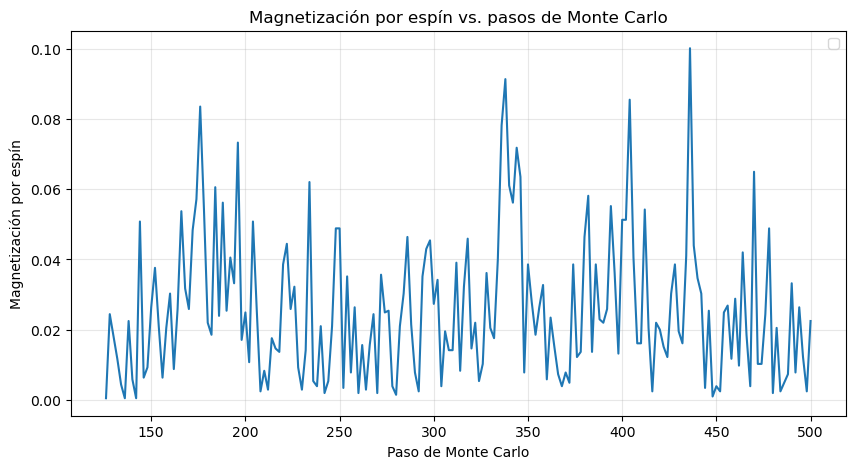

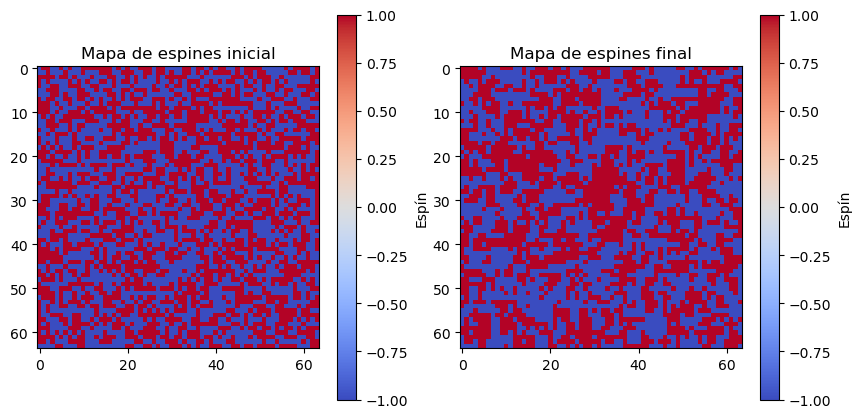

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(step_sampled, vect_mag)
plt.title("Magnetización por espín vs. pasos de Monte Carlo")
plt.xlabel("Paso de Monte Carlo")
plt.ylabel("Magnetización por espín")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


maps_story_0 = maps_story[0]
maps_story_last = maps_story[-1]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(maps_story_0, cmap="coolwarm", interpolation="nearest")
plt.title("Mapa de espines inicial")
plt.colorbar(label="Espín")
plt.subplot(1, 2, 2)
plt.imshow(maps_story_last, cmap="coolwarm", interpolation="nearest")
plt.title(f"Mapa de espines final")
plt.colorbar(label="Espín")
plt.show()

### Lanzamiento de múltiples simulaciones (procesamiento multihilo)
Hemos visto que el programa funciona correctamente, hemos *prototipado* en Python el programa. Sabemos que funciona, y que los resultados tienen sentido físico. Tenemos ahora que dar el salto profesional.

Es hora de hacer barridos de parámetros, ejecutar la simulación múltiples veces, para ver como se comporta el sistema para diferentes configuraciones. 

Para ello, tratamos el procesador local como un cluster, donde cada núcleo de alto rendimiento es un nodo de cómputo, y puede admitir un proceso de simulación completo de principio a fin (cada realización es ejecutada en *single-core*. En procesadores modernos suelen haber núcleos de alto rendimieto (*P-cores*) y núcleos de eficiencia energética (*e-cores*). Vamos a intentar usarlos todos.

Queremos:
- Acelerar bucle Python --> velocidades de C o Fortran serían deseables --> solución: `Numba`
  - Recompilar lo mínimo posible (usar la caché)
- Lanzar 1 job por cada CPU, para aprovechar el *multi-core*
- Recopilar todos los resultados en un archivo en disco, para analizarlos con calma posteriormente. 

Debemos reescribir el código que ya tenemos, pensando en todo esto.

En `Numba`, podemos indicar exactamente el tipo de variables de input, y de output:

```
types.Tuple((types.float64, types.float64))(  # <-- 1. TIPO DE RETORNO
    types.int8[:, :],                         # <-- 2. Arg 1: spins (matriz 2D de enteros de 8 bits)
    types.float64,                            # <--    Arg 2: temp (flotante de 64 bits)
    types.int64,                              # <--    Arg 3: n_mcs (entero de 64 bits)
    types.int64                               # <--    Arg 4: seed (entero de 64 bits)
)
```

o podemos no indicar nada, omitir el `types` (perdiendo algo de rendimiento, dado que numba tendrá que "averiguar" los tipos de datos la primera vez de ejecución). Por comodidad, no vamos a indicar nada.

In [9]:
from numba import njit

@njit(cache=True,     # Guarda el binario en disco; no recompila entre workers ni reinicios
    fastmath=True,    # Instrucciones vectoriales rápidas en LLVM
    nogil=True
)

def _metropolis_kernel_numba(spins, temp, n_mcs, seed):
    np.random.seed(seed)
    L = spins.shape[0]
    eq_mcs = n_mcs // 4 # descartamos el primer 25% de pasos temporales para ubicarnos en la región de equilibrio (aprox)
    n_total_steps = n_mcs * (L * L)
    
    # Acumulador entero de 64 bits para evitar overflow
    # usando numba, no tenemos problemas por usar dobles bucles, no perdemos rendimiento respecto a np.sum
    current_m = 0
    for r in range(L):
        for c in range(L):
            current_m += spins[r, c]
    # podríamos haber usado "current_m = np.sum(spins, dtype=np.int64)"

    
    # Número de muestras en fase de producción (muestreo cada 2 MCS)
    n_samples_max = (n_mcs - eq_mcs) // 2 + 1
    m_samples = np.empty(n_samples_max, dtype=np.float64) # en numba es recomendable no inicializar una lista vacía y usar append
    # np.empty reserva el bloque de memoria pero no lo inicializa: contiene "basura" numérica (valores aleatorios residuales de la RAM).
    # es perfecto para sobreescribirlo, y luego quedarnos con únicamente el fragmento escrito por nosotros (descartar lo demás)
    sample_idx = 0
    
    for step in range(n_total_steps):
        # selección de un espín aleatorio
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        s = spins[i, j]
        
        # Fronteras abiertas (Open Boundary Conditions)
        nb_sum = 0
        if i + 1 < L:  nb_sum += spins[i + 1, j]
        if i - 1 >= 0: nb_sum += spins[i - 1, j]
        if j + 1 < L:  nb_sum += spins[i, j + 1]
        if j - 1 >= 0: nb_sum += spins[i, j - 1]
        
        dE = 2 * s * nb_sum
        
        # Criterio de Metropolis
        if dE <= 0 or np.random.random() < np.exp(-dE / temp):
            spins[i, j] = -s
            current_m += 2 * (-s)
            
        # Muestreo cada 2 MCS tras termalización
        if (step + 1) % (L * L) == 0:
            mcs = (step + 1) // (L * L)
            if mcs >= eq_mcs and mcs % 2 == 0:
                m_samples[sample_idx] = abs(current_m) / (L * L)
                sample_idx += 1
                
    valid_samples = m_samples[:sample_idx] # importante para no quedarnos con la basura numérica que creamos en np.empty
    mean_m = np.mean(valid_samples)
    var_m = np.var(valid_samples)
    
    return mean_m, var_m


def _simulate_ising_job(temp: float, seed: int, L: int = 64, n_mcs: int = 4_000) -> dict:
    """Wrapper Python ejecutado en cada núcleo de forma aislada."""
    spins = np.random.choice(np.array([-1, 1], dtype=np.int8), size=(L, L))
    mean_m, var_m = _metropolis_kernel_numba(spins, float(temp), int(n_mcs), int(seed))
    
    return {
        "temperature": float(temp),
        "seed": int(seed),
        "L": int(L),
        "mean_abs_m": float(mean_m),
        "susceptibility": float((L**2 / temp) * var_m)
    }

In [ ]:
## CONFIGURACIÓN DEL EQUIPO LOCAL "COMO CLÚSTER"

# 1. Recursos totales del sistema
p_cores = 6
e_cores = 14
total_workers = p_cores + e_cores  # 20 núcleos físicos reales en total
ram_gb = 32

# 2. Partición estricta de memoria (Margen de seguridad de 6 GB para el SO y Jupyter)
# Dividimos los 26 GB útiles entre los 20 workers para que ninguno colapse el sistema
ram_per_worker = f"{(ram_gb - 6) / total_workers:.2f}GB"  # ~1.30 GB por worker

workers_dict = {}

# 3. Configuración de Workers en P-Cores
for idx in range(p_cores):
    workers_dict[f"p-core-{idx}"] = {
        "cls": Worker,
        "options": {
            "nthreads": 1,                      # 1 proceso aislado = 1 CPU física fija
            "memory_limit": ram_per_worker,     # Límite duro de RAM por proceso
            "resources": {"CORE": 1, "P_CORE": 1} # Etiqueta de hardware para Dask
        }
    }

# 4. Configuración de Workers en E-Cores
for idx in range(e_cores):
    workers_dict[f"e-core-{idx}"] = {
        "cls": Worker,
        "options": {
            "nthreads": 1,
            "memory_limit": ram_per_worker,
            "resources": {"CORE": 1, "E_CORE": 1} # Permite filtrar tareas por tipo de núcleo
        }
    }

# 5. Instanciación del Clúster
cluster = SpecCluster(workers=workers_dict)
client = Client(cluster)

2026-08-18 19:51:25,447 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-18 19:51:25,476 - distributed.scheduler - INFO - State start
2026-08-18 19:51:25,478 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-6ast5qf4', purging
2026-08-18 19:51:25,479 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-gibzwglu', purging
2026-08-18 19:51:25,480 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-zn8kuc5k', purging
2026-08-18 19:51:25,481 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-yo1qgddl', purging
2026-08-18 19:51:25,482 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-d975usg2', purging
2026-08-18 19:51:25,484 - dist

2026-08-18 19:51:45,937 - distributed.worker - ERROR - Compute Failed
Key:       _simulate_ising_job-36ed468a7beb62e29842e54db14d0fb8
State:     executing
Task:  <Task '_simulate_ising_job-36ed468a7beb62e29842e54db14d0fb8' _simulate_ising_job(..., ...)>
Exception: 'TypeError("int() argument must be a string, a bytes-like object or a real number, not \'list\'")'
Traceback: '  File "/tmp/ipykernel_14183/4044510648.py", line 67, in _simulate_ising_job\n    mean_m, var_m = _metropolis_kernel_numba(spins, float(temp), int(n_mcs), int(seed))\n                                                                             ^^^^^^^^^\n'

2026-08-18 19:51:45,937 - distributed.worker - ERROR - Compute Failed
Key:       _simulate_ising_job-6ebcccf57f08fd5023990625027f6e06
State:     executing
Task:  <Task '_simulate_ising_job-6ebcccf57f08fd5023990625027f6e06' _simulate_ising_job(..., ...)>
Exception: 'TypeError("int() argument must be a string, a bytes-like object or a real number, not \'list\'")'
Tr

In [19]:
## LANZAMIENTO DE JOBS CON DASK


# DEFINICIÓN DE PARÁMETROS DE BARRIDO

temperatures = np.linspace(1.4, 3.2, 32)  # 32 temperaturas
n_replicas = 16                           # 16 realizaciones independientes por T
total_jobs = len(temperatures) * n_replicas

# 2. Construcción de las listas emparejadas para Dask
temp_list = []
for t in temperatures:
    temp_list.extend([float(t)] * n_replicas)

# Generación estricta de semillas independientes
seed_sequence = np.random.SeedSequence(2026)
seeds = [int(s) for s in seed_sequence.generate_state(total_jobs)]

print(f"[+] Total de simulaciones a ejecutar: {total_jobs}")
print(f"[+] Número de temperaturas: {len(temperatures)}")
print(f"[+] Réplicas por temperatura: {n_replicas}")

########################################################
# Despacho asíncrono a los Workers y Barra de Progreso #
########################################################

from dask.distributed import progress

# Despachamos las tareas al cluster de Dask
futures = client.map(
    _simulate_ising_job,
    temp_list,                  # Variable: temperatura
    seeds,                 # Variable: semilla independiente
    L=64,                       # Constante: tamaño de red 64x64
    n_mcs=50_000                 # Constante: 5000 MCS por realización
)

# Renderiza la barra de progreso interactiva en el notebook
progress(futures)

[+] Total de simulaciones a ejecutar: 512
[+] Número de temperaturas: 32
[+] Réplicas por temperatura: 16


VBox()

In [20]:
## INSPECCIÓN DE LOS RESULTADOS: 
# Ejemplo: resultado del primer Job (Job 0)

primer_resultado = futures[0].result()

print("Claves disponibles:", primer_resultado.keys())
print("Detalle del Job 0:")
for key, value in primer_resultado.items():
    print(f"  {key}: {value}")


# Inspección de resultados (globalmente)
resultados = client.gather(futures)

print(60 * "-")
print(f"Total jobs recuperados: {len(resultados)}")

# Ver los 3 primeros jobs
for r in resultados[:32]:
    print(f"T = {r['temperature']:.3f} | Seed = {r['seed']} | <|M|> = {r['mean_abs_m']:.4f} | Chi = {r['susceptibility']:.4f}")

Claves disponibles: dict_keys(['temperature', 'seed', 'L', 'mean_abs_m', 'susceptibility'])
Detalle del Job 0:
  temperature: 1.4
  seed: 2727543821
  L: 64
  mean_abs_m: 0.9879699905588368
  susceptibility: 0.030072631563917922
------------------------------------------------------------
Total jobs recuperados: 512
T = 1.400 | Seed = 2727543821 | <|M|> = 0.9880 | Chi = 0.0301
T = 1.400 | Seed = 2207150826 | <|M|> = 0.9880 | Chi = 0.0286
T = 1.400 | Seed = 508070823 | <|M|> = 0.6777 | Chi = 410.8232
T = 1.400 | Seed = 1505698380 | <|M|> = 0.9881 | Chi = 0.0290
T = 1.400 | Seed = 1703033196 | <|M|> = 0.9880 | Chi = 0.0301
T = 1.400 | Seed = 1600338967 | <|M|> = 0.9880 | Chi = 0.0293
T = 1.400 | Seed = 1277837829 | <|M|> = 0.9880 | Chi = 0.0298
T = 1.400 | Seed = 1857762792 | <|M|> = 0.9880 | Chi = 0.0305
T = 1.400 | Seed = 3160045732 | <|M|> = 0.9881 | Chi = 0.0286
T = 1.400 | Seed = 3296285949 | <|M|> = 0.9880 | Chi = 0.0298
T = 1.400 | Seed = 3689327497 | <|M|> = 0.1565 | Chi = 37.009

--- Primeras filas ---


,temperature,seed,L,mean_abs_m,susceptibility
0,1.4,2727543821,64,0.987970,0.030073
1,1.4,2207150826,64,0.988013,0.028573
2,1.4,508070823,64,0.677709,410.823189



--- Resumen estadístico global ---


,temperature,seed,L,mean_abs_m,susceptibility
count,512.000000,5.120000e+02,512.0,512.000000,512.000000
mean,2.300000,2.150000e+09,64.0,0.440810,16.967268
std,0.536639,1.254727e+09,0.0,0.402935,51.625497
min,1.400000,2.938140e+07,64.0,0.034355,0.028573
25%,1.806452,1.594128e+09,64.0,0.051674,0.907882
50%,2.300000,2.454995e+09,64.0,0.221868,2.064716
75%,2.735484,3.300595e+09,64.0,0.907081,10.236019
max,3.200000,4.283075e+09,64.0,0.988069,410.823189


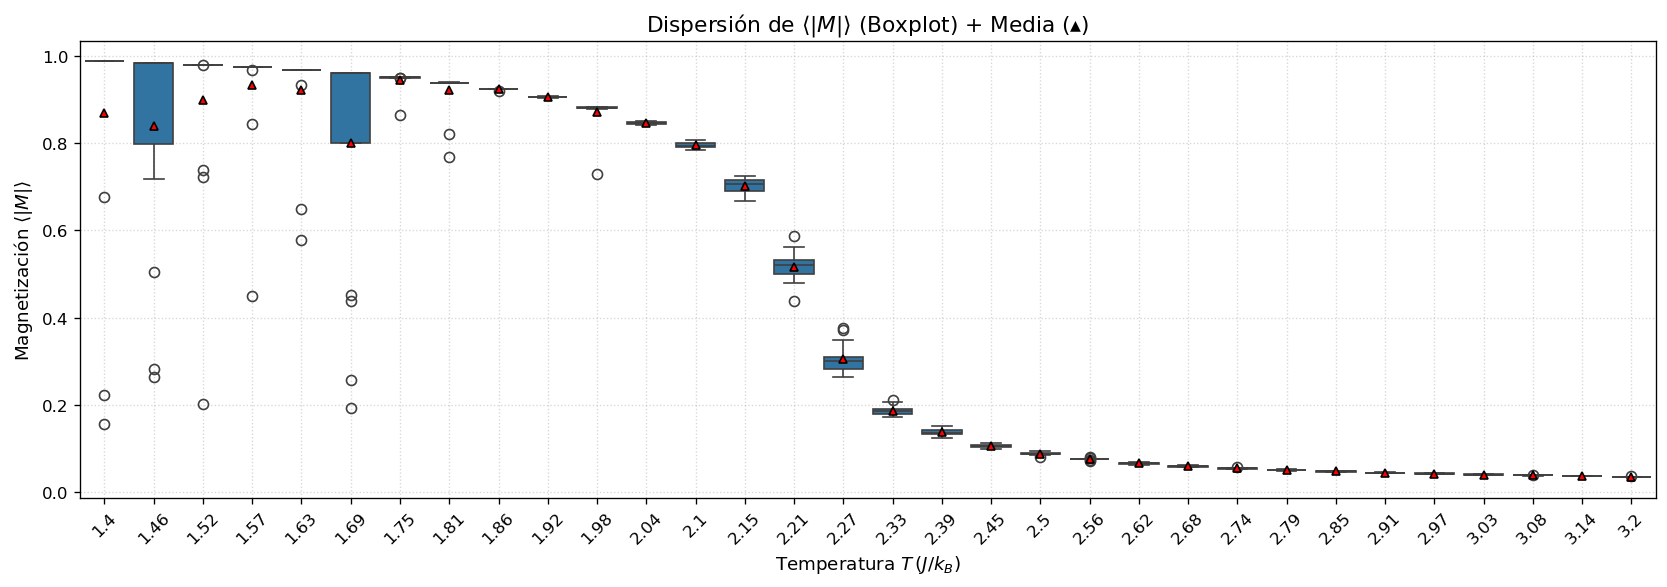

In [21]:
# para inspeccionar correctamente, lo mejor es usar un DataFrame (ya sea Pandas, Dask, Polars, ...)
# Vamos a usarlo de Dask nosotros, así podemos trabajar con datasets más grandes que la RAM disponible y hacer operaciones paralelas de forma sencilla.

import dask.bag as db

# 1. Convertir los futures a Dask DataFrame
ddf = db.from_sequence(futures).to_dataframe() # dask dataframe

# 2. Ver las primeras 5 filas (head)
print("--- Primeras filas ---")
display(ddf.head())

# 3. Resumen estadístico rápido de todas las variables
print("\n--- Resumen estadístico global ---")
display(ddf.describe().compute())


# Vamos a hacer un BoxPlot de la magnetización por espín <|M|> vs. temperatura T, así podemos visualizar la dispersión de los resultados de las 16 réplicas por cada temperatura.
# Las librerías de visualización requieren traer a RAM los datos. Si tuvieramos millones de simulaciones MC, y queremos hacer plots, tendríamos que sub-samplear o hacer agregaciones estadísticas (media, mediana, percentiles) para no saturar la RAM.

import seaborn as sns
df = ddf.compute() # esto trae a RAM el DataFrame completo, que en este caso es pequeño (32 temperaturas * 16 réplicas = 512 filas), directamente en Pandas DataFrame.

plt.figure(figsize=(14, 5), dpi=120)

df["T_label"] = df["temperature"].round(2) # Redondeamos temporalmente T a 2 decimales para que las etiquetas del eje X sean legibles

sns.boxplot(
    data=df, 
    x="T_label", 
    y="mean_abs_m", 
    showmeans=True,
    meanprops=dict(marker="^", markeredgecolor="black", markerfacecolor="red", markersize=5)
)

plt.title(r"Dispersión de $\langle |M| \rangle$ (Boxplot) + Media ($\blacktriangle$)", fontsize=13)
plt.xlabel(r"Temperatura $T \, (J/k_B)$", fontsize=11)
plt.ylabel(r"Magnetización $\langle |M| \rangle$", fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()
